# Reproduce Natalie first, then audit each change
This notebook starts from Natalie's saved per-frame profiles and reproduces **24.90 Å WT / 30.78 Å AA**. It then changes one choice at a time. The source notebooks and HDF5 files are not modified. Frames and q indices are zero based, with both endpoints included.

A changed fit convention is a methodological choice, not evidence that Natalie's result is wrong. q-range sensitivity, background covariance, and a newly selected window must be distinguished. P(r) and Guinier estimates are compared separately.

In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
ROOT=Path.cwd()
sys.path.insert(0,str(ROOT/'analysis'))
from inspect_data import load, correct
from select_windows import average
from run_efa import guinier
%matplotlib inline


## 1. Data provenance and exact averaging
The saved DAT files contain Natalie’s processed intensities and errors. An arithmetic mean has variance sum(sigma²)/n² when frames are treated as independent; we first reproduce that convention.

In [2]:
saved={}; hashes={}
for name,a,b in [('WT_092025',175,185),('AA_052026',172,182)]:
    paths=[ROOT/'BNL_SAXS/dat_files'/name/f'profile_{j}.dat' for j in range(a,b+1)]
    d=np.array([np.loadtxt(p) for p in paths])
    saved[name]=(d[0,:,0],d[:,:,1].mean(0),np.sqrt((d[:,:,2]**2).sum(0))/len(d))
    for p in paths: hashes[str(p.relative_to(ROOT))]=hashlib.sha256(p.read_bytes()).hexdigest()
    print(name, 'frames',a,b,'number',len(d))
print('All input file hashes retained in results/reproduction_input_hashes.json')
(ROOT/'results/reproduction_input_hashes.json').write_text(json.dumps(hashes,indent=2));


WT_092025 frames 175 185 number 11
AA_052026 frames 172 182 number 11
All input file hashes retained in results/reproduction_input_hashes.json


## 2. Show the fit equation and reproduce the reported values
$$y_i=\ln I_i=a+bq_i^2,\quad \sigma_{y_i}=\sigma_{I_i}/I_i,$$
$$\hat\beta=(X^TWX)^{-1}X^TWy,\quad R_g=\sqrt{-3b},\quad I(0)=e^a.$$
This is RAW's error-weighted linear Guinier fit. The uncertainty below is the conditional covariance error; RAW can additionally report the larger fit-range variation error. WT uses q indices 3–45; AA uses 3–41, verified against saved notebook outputs.

In [3]:
def fixed_fit(q,I,E,lo,hi):
    m=(q>=lo-1e-12)&(q<=hi+1e-12)&(I>0)&(E>0)
    X=np.column_stack([np.ones(m.sum()),q[m]**2]); y=np.log(I[m]); sigma=E[m]/I[m]
    cov=np.linalg.inv(X.T@((1/sigma**2)[:,None]*X))
    beta=cov@(X.T@(y/sigma**2)); rg=np.sqrt(-3*beta[1])
    return dict(Rg=float(rg),fit_se=float(3*np.sqrt(cov[1,1])/(2*rg)),
                qmin=float(q[m][0]),qmax=float(q[m][-1]),qRgmax=float(q[m][-1]*rg),
                chi2=float(np.sum(((y-X@beta)/sigma)**2)/(len(y)-2)),I0=float(np.exp(beta[0])))
reproduced={}
for name,end,target in [('WT_092025',45,24.90414304),('AA_052026',41,30.78492264)]:
    q,I,E=saved[name]; f=fixed_fit(q,I,E,q[3],q[end]); reproduced[name]=f
    assert abs(f['Rg']-target)<1e-6
    print(name, f)


WT_092025 {'Rg': 24.904143040206478, 'fit_se': 0.4967861438280373, 'qmin': 0.009, 'qmax': 0.052, 'qRgmax': 1.2950154380907368, 'chi2': 1.0795553966408564, 'I0': 0.6958219904774279}
AA_052026 {'Rg': 30.78492263777366, 'fit_se': 0.11899073791382031, 'qmin': 0.008, 'qmax': 0.046, 'qRgmax': 1.4161064413375883, 'chi2': 2.1558756367660905, 'I0': 5.242626879569802}


### I(q) first, with conventional and extended Guinier side by side
These executable comparisons use the same exported curves and propagated errors. Fit ranges and conditional uncertainties are shown explicitly. The additional matched-range extended column separates model-form effects from q-range effects. See notebook07 for paired differences and full uncertainty assumptions.

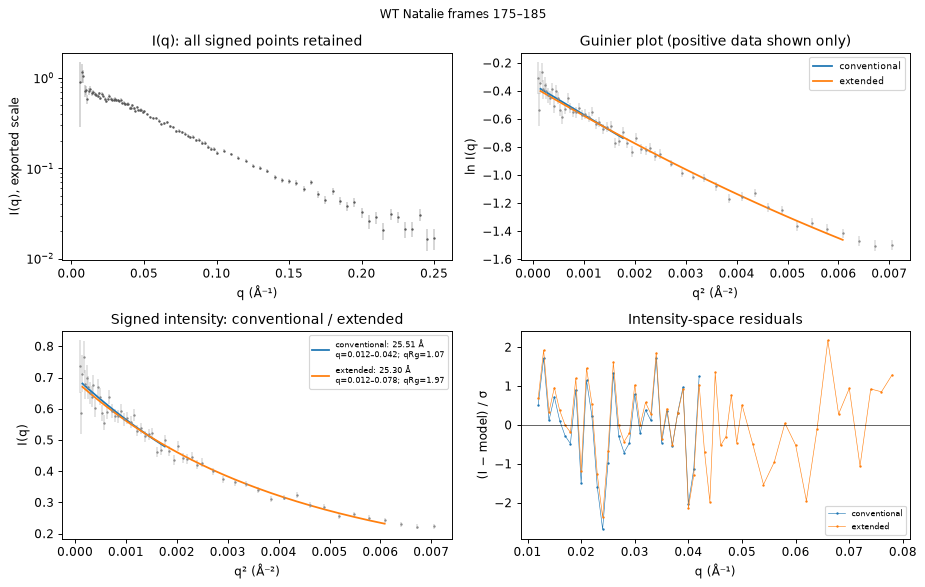

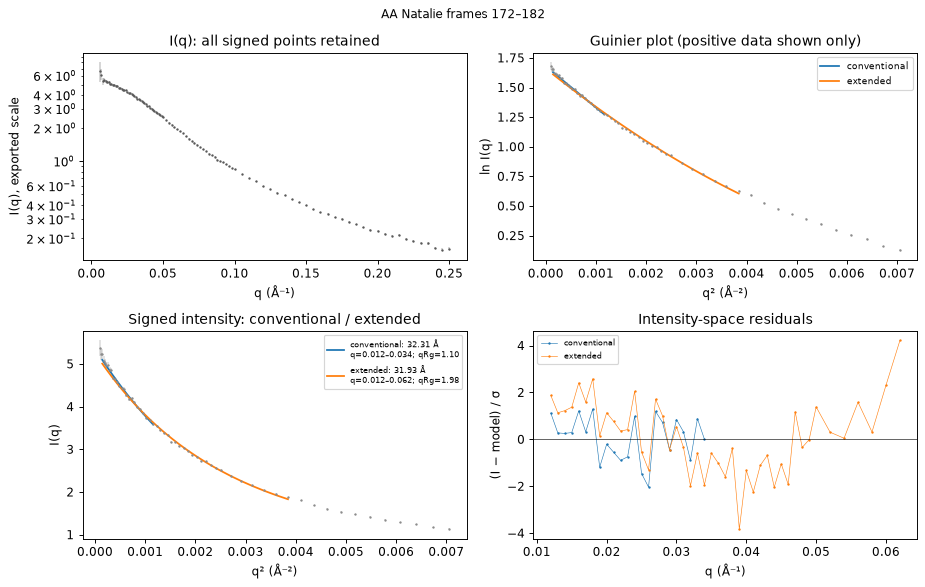

Extended residual chi-square/dof >2.

| Curve | Conventional Rg ± SE (Å) | Extended, same q range | Extended, qRg≤2 | Conditional extended 95% |
|---|---:|---:|---:|---|
|WT Natalie frames 175–185|25.51 ± 0.92|26.17 ± 1.04|25.30 ± 0.29|[24.78, 25.88]|
|AA Natalie frames 172–182|32.31 ± 0.30|33.70 ± 0.36|31.93 ± 0.09|[31.74, 32.11]|


In [1]:
from pathlib import Path
import sys,json,numpy as np
from IPython.display import display,Markdown
ROOT=Path.cwd()
if not (ROOT/'analysis/compare_all_iq.py').exists(): ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'analysis'))
from compare_all_iq import *
%matplotlib inline

_all=json.loads((OUT/'fit_results.json').read_text())
comparison_rows=gallery(_all,['Original averages'])

## 3. One change at a time
Stage A reproduces Natalie. B changes only the q fit convention (start 0.012 Å⁻¹, initial upper bound 0.04 Å⁻¹, iteratively reduce until qRg≤1). This conservative iteration can retain a slightly shorter interval than the longest admissible prefix. C retains exactly B's q points and intensities but propagates shared background covariance. D updates the residual-background estimator while keeping those same q points. E changes the averaging window only. F reapplies the conservative q-range rule to the selected window.

The WT corrected intensities reproduce the DAT values to their saved precision. AA differs slightly because the new weighted baseline fit uses original HDF5 errors rather than errors after residual-buffer subtraction. These are numerical changes with explicit assumptions, not an independently established correction to the instrument data.

In [4]:
rows=[]
for name,a,b,newa,newb in [('WT_092025',175,185,159,175),('AA_052026',172,182,169,188)]:
    q,I,E=saved[name]; B=guinier(q,I,E); lo,hi=B['qmin'],B['qmax']
    q2,I2,E2=average(name,a,b); assert np.allclose(q,q2)
    q3,I3,E3=average(name,newa,newb)
    stages=[('A saved profiles, original fit',reproduced[name]),
            ('B change q range only',B),
            ('C shared background error only',fixed_fit(q,I,E2,lo,hi)),
            ('D updated baseline estimator',fixed_fit(q,I2,E2,lo,hi)),
            ('E selected frames, same q points',fixed_fit(q3,I3,E3,lo,hi)),
            ('F selected frames, qRg rule',guinier(q3,I3,E3))]
    rows.extend(dict(sample=name,stage=label,**f) for label,f in stages)
    print(name, 'maximum profile change at original window:',np.max(abs(I-I2)))
header='| Sample | Stage | Rg (Å) | conditional SE | qmin–qmax (Å⁻¹) | qmax Rg |\n|---|---|---:|---:|---|---:|\n'
display(Markdown(header+'\n'.join(f"|{r['sample']}|{r['stage']}|{r['Rg']:.3f}|{r['fit_se']:.3f}|{r['qmin']:.3f}–{r['qmax']:.3f}|{r['qRgmax']:.3f}|" for r in rows)))
(ROOT/'results/Rg_correction_audit.json').write_text(json.dumps(rows,indent=2));


WT_092025 maximum profile change at original window: 1.4229415423727687e-09
AA_052026 maximum profile change at original window: 0.00044627566820309994


| Sample | Stage | Rg (Å) | conditional SE | qmin–qmax (Å⁻¹) | qmax Rg |
|---|---|---:|---:|---|---:|
|WT_092025|A saved profiles, original fit|24.904|0.497|0.009–0.052|1.295|
|WT_092025|B change q range only|25.216|1.260|0.012–0.038|0.958|
|WT_092025|C shared background error only|25.215|1.548|0.012–0.038|0.958|
|WT_092025|D updated baseline estimator|25.215|1.548|0.012–0.038|0.958|
|WT_092025|E selected frames, same q points|25.791|0.584|0.012–0.038|0.980|
|WT_092025|F selected frames, qRg rule|25.791|0.584|0.012–0.038|0.980|
|AA_052026|A saved profiles, original fit|30.785|0.119|0.008–0.046|1.416|
|AA_052026|B change q range only|32.428|0.473|0.012–0.030|0.973|
|AA_052026|C shared background error only|32.398|0.555|0.012–0.030|0.972|
|AA_052026|D updated baseline estimator|32.398|0.555|0.012–0.030|0.972|
|AA_052026|E selected frames, same q points|32.346|0.509|0.012–0.030|0.970|
|AA_052026|F selected frames, qRg rule|32.346|0.509|0.012–0.030|0.970|

### I(q) first, with conventional and extended Guinier side by side
These executable comparisons use the same exported curves and propagated errors. Fit ranges and conditional uncertainties are shown explicitly. The additional matched-range extended column separates model-form effects from q-range effects. See notebook07 for paired differences and full uncertainty assumptions.

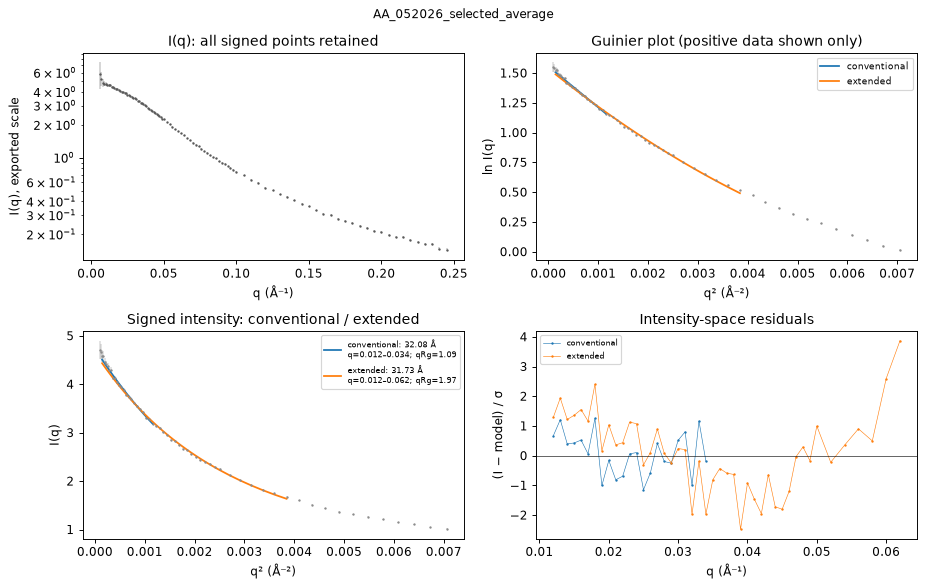

Component identity and physical validity are not established by a converged fit.

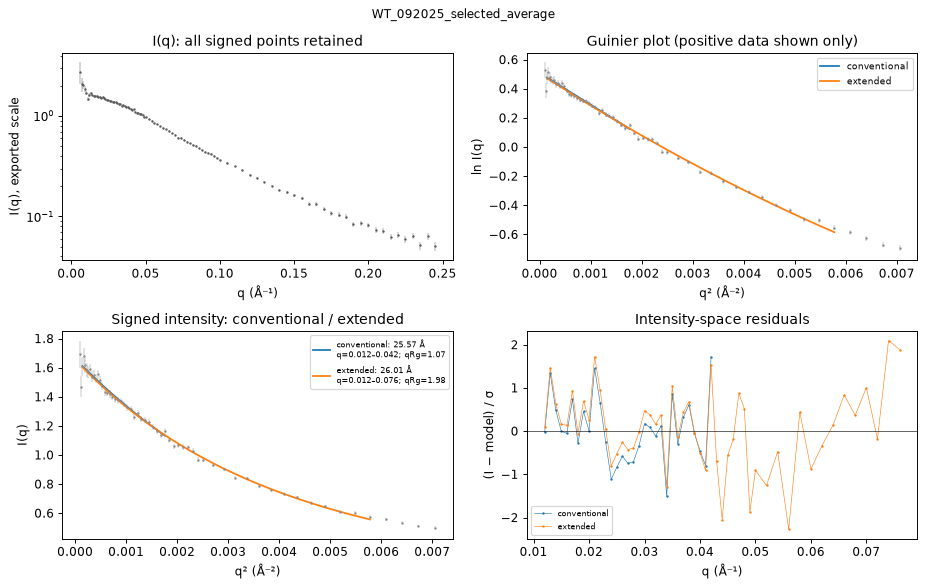

Component identity and physical validity are not established by a converged fit.

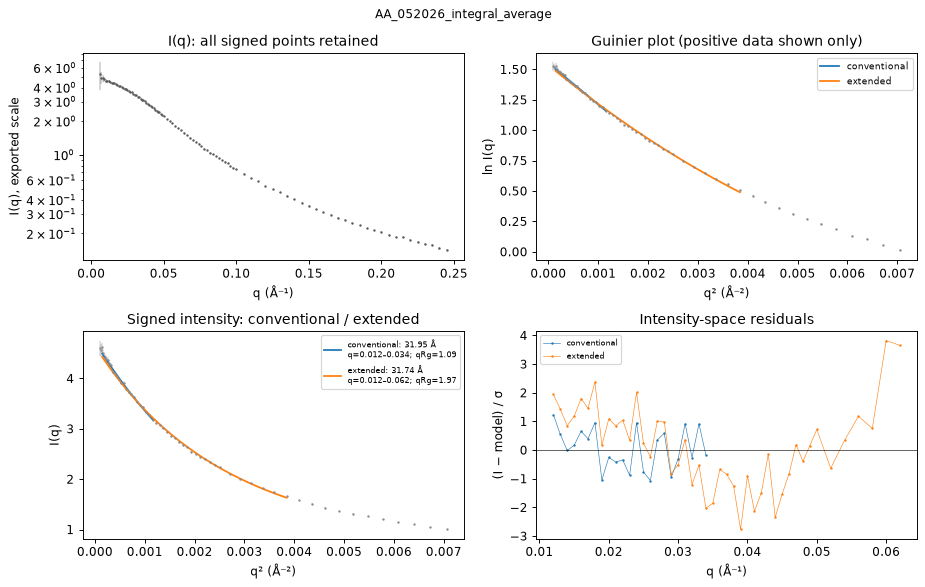

Extended residual chi-square/dof >2.

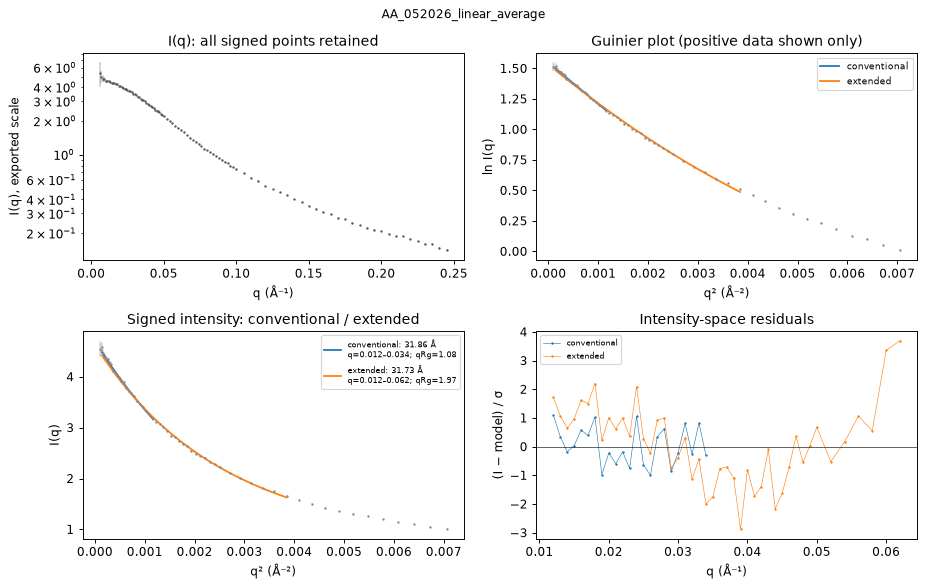

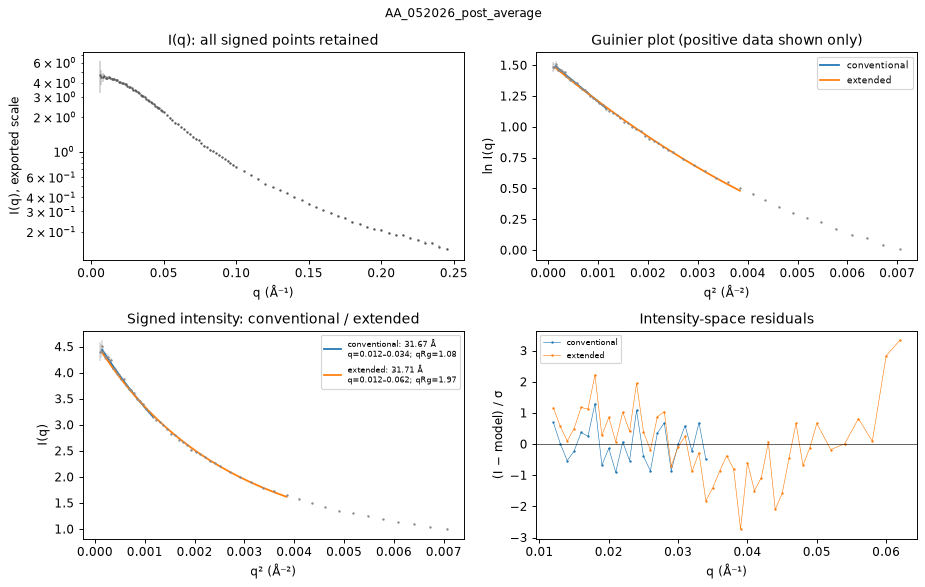

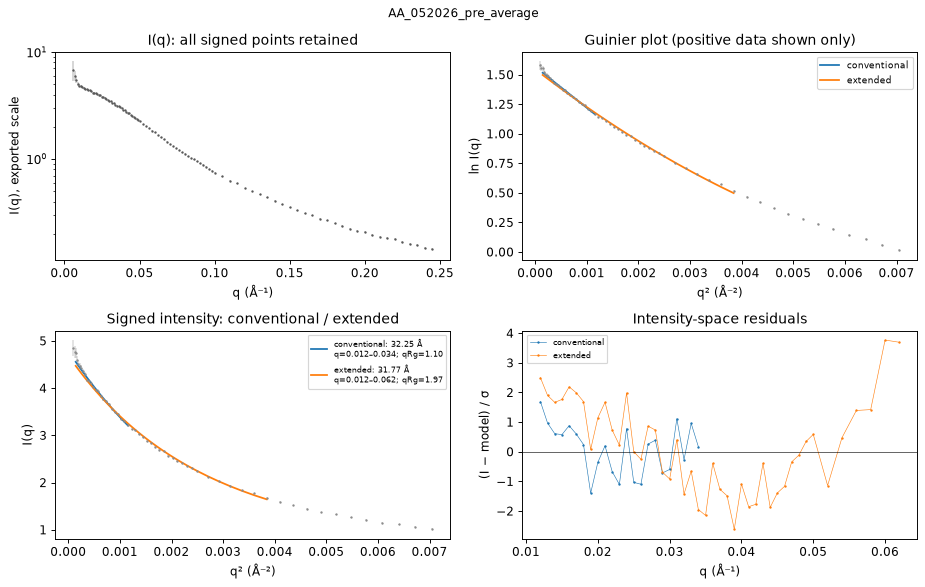

Extended residual chi-square/dof >2.

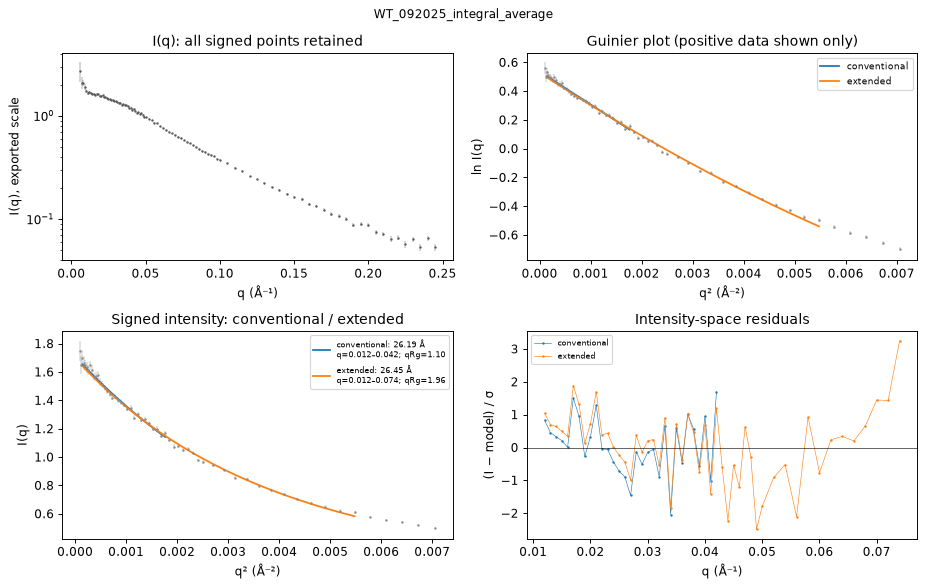

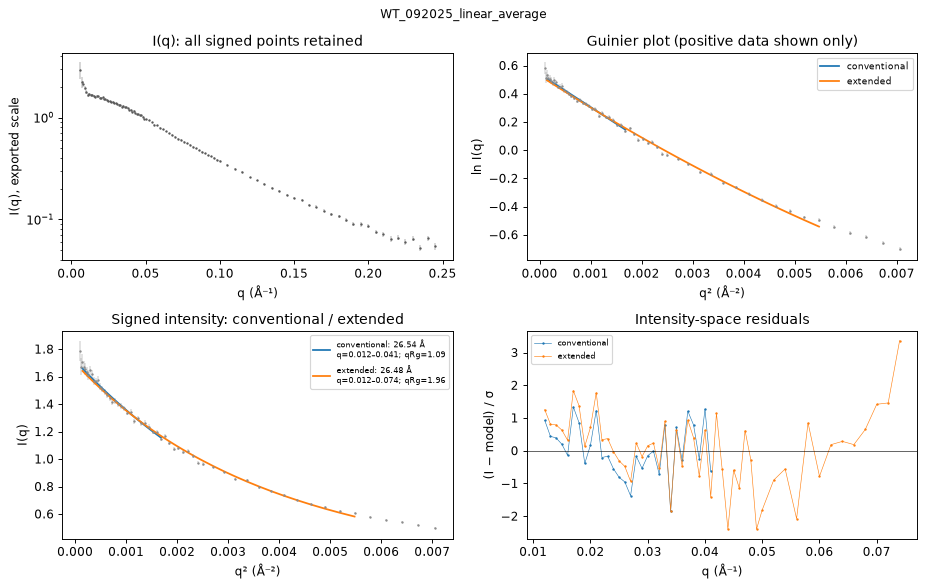

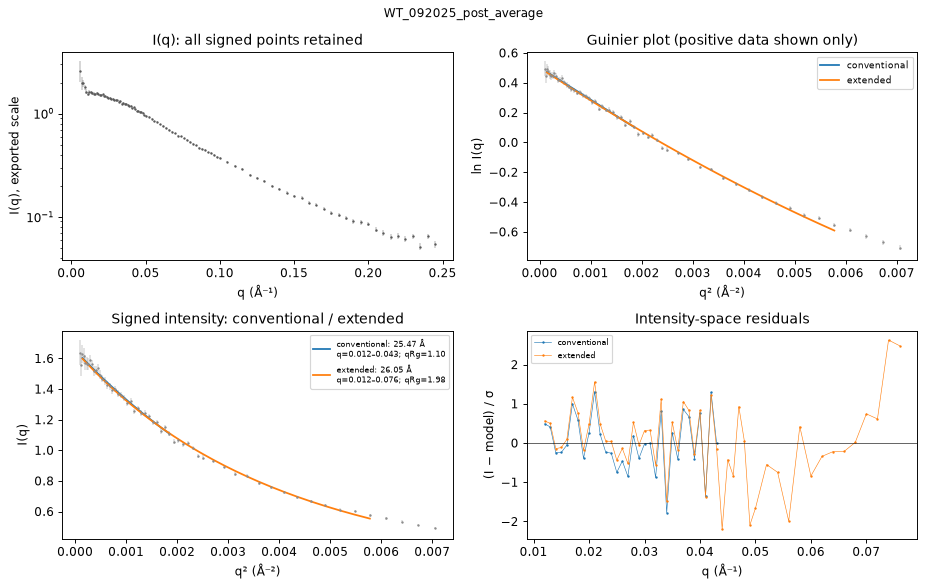

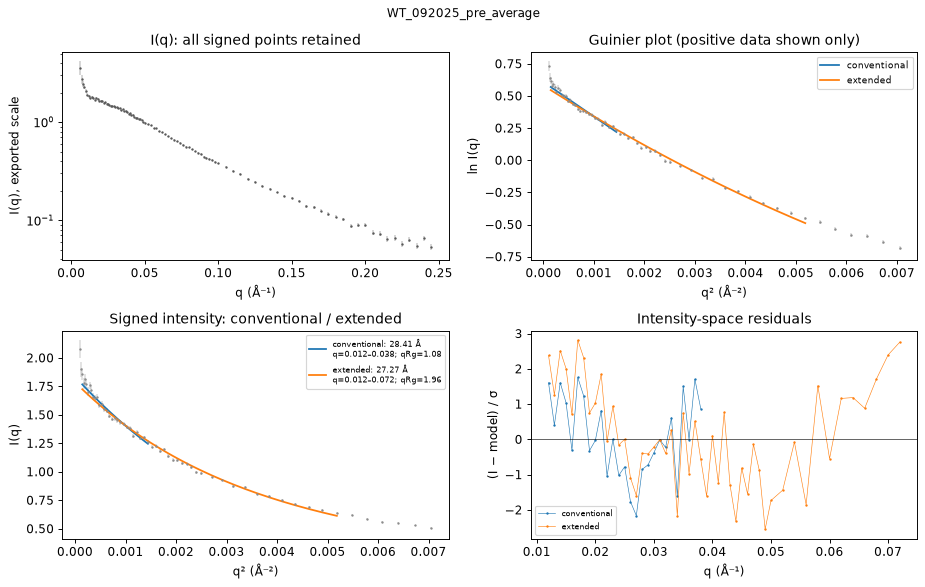

Extended residual chi-square/dof >2.

| Curve | Conventional Rg ± SE (Å) | Extended, same q range | Extended, qRg≤2 | Conditional extended 95% |
|---|---:|---:|---:|---|
|AA_052026_selected_average|32.08 ± 0.33|33.45 ± 0.39|31.73 ± 0.10|[31.54, 31.93]|
|WT_092025_selected_average|25.57 ± 0.43|26.35 ± 0.49|26.01 ± 0.14|[25.75, 26.29]|
|AA_052026_integral_average|31.95 ± 0.28|33.30 ± 0.32|31.74 ± 0.08|[31.58, 31.9]|
|AA_052026_linear_average|31.86 ± 0.29|33.18 ± 0.34|31.73 ± 0.09|[31.56, 31.9]|
|AA_052026_post_average|31.67 ± 0.31|32.94 ± 0.37|31.71 ± 0.09|[31.53, 31.89]|
|AA_052026_pre_average|32.25 ± 0.29|33.65 ± 0.34|31.77 ± 0.09|[31.6, 31.94]|
|WT_092025_integral_average|26.19 ± 0.34|27.07 ± 0.39|26.45 ± 0.12|[26.23, 26.68]|
|WT_092025_linear_average|26.54 ± 0.37|27.42 ± 0.42|26.48 ± 0.12|[26.26, 26.72]|
|WT_092025_post_average|25.47 ± 0.37|26.28 ± 0.41|26.05 ± 0.13|[25.82, 26.31]|
|WT_092025_pre_average|28.41 ± 0.43|29.42 ± 0.49|27.27 ± 0.13|[27.02, 27.51]|


In [2]:
from pathlib import Path
import sys,json,numpy as np
from IPython.display import display,Markdown
ROOT=Path.cwd()
if not (ROOT/'analysis/compare_all_iq.py').exists(): ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'analysis'))
from compare_all_iq import *
%matplotlib inline

_all=json.loads((OUT/'fit_results.json').read_text())
comparison_rows=gallery(_all,['Baseline variants', 'Selected non-EFA'])

## 4. Observe q-range sensitivity directly
The data and errors are unchanged across each curve below. Curvature outside the lowest-q regime can change the fitted slope, particularly for the expanded AA sample. Shorter fits also have larger statistical uncertainty.

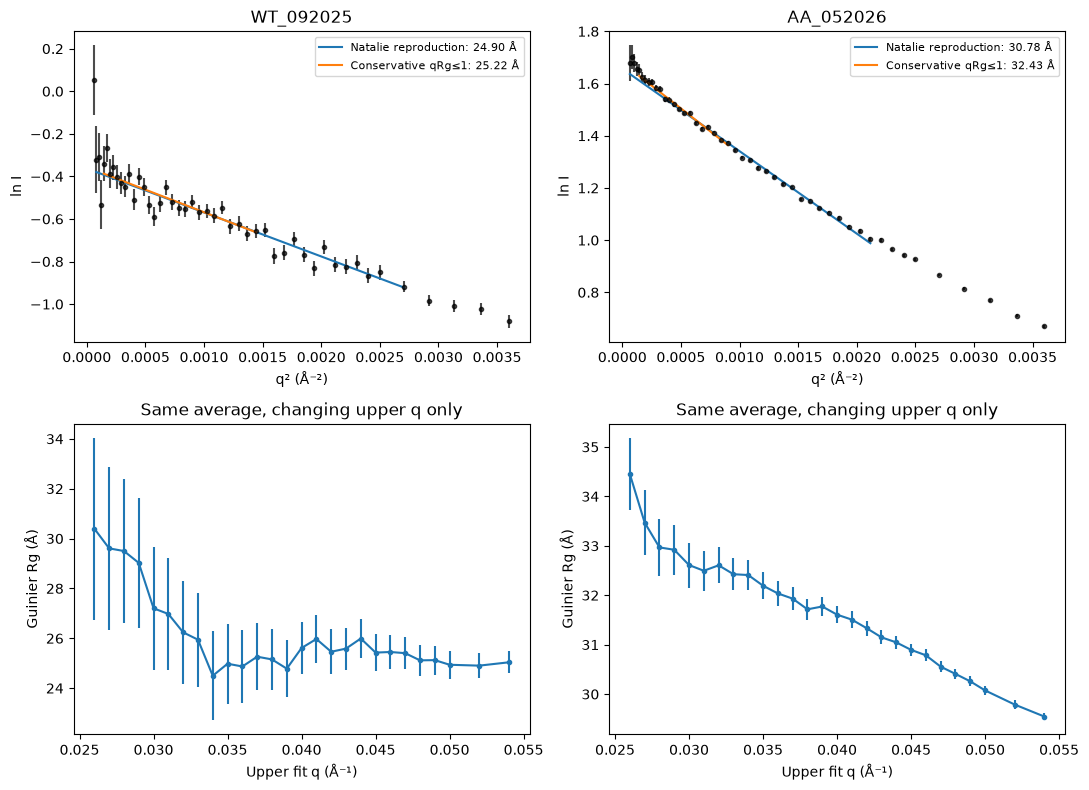

In [5]:
fig,axes=plt.subplots(2,2,figsize=(11,8))
for col,name in enumerate(saved):
    q,I,E=saved[name]; ref=reproduced[name]; narrow=guinier(q,I,E)
    m=(q>=.008)&(q<=.06)&(I>0)
    ax=axes[0,col]; ax.errorbar(q[m]**2,np.log(I[m]),yerr=E[m]/I[m],fmt='.',alpha=.7,color='black')
    for f,label in [(ref,'Natalie reproduction'),(narrow,'Conservative qRg≤1')]:
        x=np.array([f['qmin'],f['qmax']])**2
        ax.plot(x,np.log(f['I0'])-f['Rg']**2*x/3,label=f"{label}: {f['Rg']:.2f} Å")
    ax.set(title=name,xlabel='q² (Å⁻²)',ylabel='ln I'); ax.legend(fontsize=8)
    ends=q[(q>=.026)&(q<=.055)]; fits=[fixed_fit(q,I,E,q[3],end) for end in ends]
    axes[1,col].errorbar(ends,[f['Rg'] for f in fits],yerr=[f['fit_se'] for f in fits],fmt='o-',markersize=3)
    axes[1,col].set(xlabel='Upper fit q (Å⁻¹)',ylabel='Guinier Rg (Å)',title='Same average, changing upper q only')
fig.tight_layout();fig.savefig(ROOT/'poster_results/Rg_reproduction_and_qrange.png',dpi=200)
display(fig);plt.close(fig)


## 5. P(r) is a separate estimate
Natalie's supplied poster reports GNOM Rg **27.3 Å WT / 34.23 Å AA**, with Dmax **95 / 139 Å**. Our current BIFT estimates are about **27.22 / 34.60 Å** with Dmax **94 / 159 Å**. The AA Guinier discrepancy is largely reproduced by changing the fitted q range on the *same data*. The P(r) Rg estimates are already close, but the AA Dmax difference remains material. GNOM and BIFT regularization/Dmax selection differ; neither should be silently substituted for the other. We have not rerun GNOM or established a unique AA Dmax.

A 35 Å Rg is not by itself evidence of oligomerization in an IDR. The size of this sequence must be assessed with the full scattering curve, concentration behavior, uncertainty and ideally an independent mass measurement. No window was selected by closeness to a desired Rg.

## New report context
WT_raw_report.pdf records buffer frames 210–239 plus a linear baseline using 0–10 and 439–449; this differs from the source DAT correction (220–236). Its four proposed component intervals overlap strongly; the report does not display recovered component curves. AA_raw_report.pdf shows a three-component rotation over 117–250, including q out to 3.19 Å⁻¹; two recovered curves are very noisy. These are analysis settings/results, not proof of four WT or three AA biological species. Notebook 03 checks their sensitivity.